In [2]:
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import yaml
import os.path as op
import scanpy as sc
import numpy as np
import pandas as pd




In [4]:


def read_all_results2(root_dir, select = ('overlaps_global_top_k_quantile_count.tsv')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(select) and filename == 'preclustered_overlaps_global_top_k.tsv':

                filepath = os.path.join(dirpath, filename)
                print(filepath)
                try:
                    overlaps = pd.read_csv(filepath, sep = '\t', index_col=0)
                    overlaps['net'] = op.basename(op.dirname(filepath))
                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results

def read_all_results(root_dir, select = ('overlaps_global_top_k_quantile_count.tsv')):
    """
    Reads all YAML files in a tree of directories starting from root_dir.extended
    Args: 
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file.
    """
    all_results = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_results

    for dirpath, dirnames, filenames in os.walk(root_dir):
        print(dirpath)
        print(dirnames)
        print(filenames)
        for filename in filenames:
            if filename.endswith(select) and filename == select:

                filepath = os.path.join(dirpath, filename)
                try:
                    print(filepath)
                    overlaps = pd.read_csv(filepath, sep = '\t')
                    overlaps['net'] = op.basename(op.dirname(filepath))
                    overlaps['data_config'] = filepath.split('/')[-3]

                    all_results.append(overlaps)
                except:
                    continue
    all_results = pd.concat(all_results)

                    
    return all_results

In [5]:
all_overlaps = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/net_133_10773_net_82_10152_net_72_10551/', select=('GuidedBackprop_64_3_overlaps_global_top_k.tsv'))
#grnb = read_all_results2('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/', select=('overlaps_global_top_k.tsv'))
#scgenerai = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries/config_easy/', select=('overlaps_global_top_k_averaged.tsv'))



/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/net_133_10773_net_82_10152_net_72_10551
[]
['GuidedBackprop_64_1_overlaps_global_top_k.tsv', 'GuidedBackprop_64_1_clustering_score.json', 'GradientShap_64_1_overlaps_global_top_k.tsv', 'GradientShap_64_1_clustering_score.json', 'Deconvolution_64_1_overlaps_global_top_k.tsv', 'Deconvolution_64_1_clustering_score.json', 'GuidedBackprop_64_2_overlaps_global_top_k.tsv', 'GuidedBackprop_64_2_clustering_score.json', 'GradientShap_64_2_overlaps_global_top_k.tsv', 'GradientShap_64_2_clustering_score.json', 'Deconvolution_64_2_overlaps_global_top_k.tsv', 'Deconvolution_64_2_clustering_score.json', 'GuidedBackprop_64_3_overlaps_global_top_k.tsv', 'GuidedBackprop_64_3_clustering_score.json', 'GradientShap_64_3_overlaps_global_top_k.tsv', 'GradientShap_64_3_clustering_score.json', 'Deconvolution_64_3_overlaps_global_top_k.tsv', 'Deconvolution_64_3_clustering_score.json', 'GuidedBackprop_32_1_overlaps_global_top_k.tsv', 'GuidedBackpr

In [6]:
all_overlaps

,Unnamed: 0,n_top,net,avg_edges_recovered,mean_cell_count,gold_standard_edges,max_possible_edges,target,direction,method,net_type,layer,data_config
0,0,0.001,net_133_10773_net_82_10152_net_72_10551,0,NaN,201,82369,on_target,forward,netmap_1,strict,X,summaries_new
1,1,0.010,net_133_10773_net_82_10152_net_72_10551,0,NaN,201,82369,on_target,forward,netmap_1,strict,X,summaries_new
2,2,0.050,net_133_10773_net_82_10152_net_72_10551,5,297.800000,201,82369,on_target,forward,netmap_1,strict,X,summaries_new
3,3,0.100,net_133_10773_net_82_10152_net_72_10551,30,296.833333,201,82369,on_target,forward,netmap_1,strict,X,summaries_new
4,4,0.200,net_133_10773_net_82_10152_net_72_10551,80,285.612500,201,82369,on_target,forward,netmap_1,strict,X,summaries_new
...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,31,0.200,net_133_10773_net_82_10152_net_72_10551,97,424.247423,189,82369,off_target,reverse,netmap_1,unspecific,aggregated_50,summaries_new
320,32,0.250,net_133_10773_net_82_10152_net_72_10551,110,430.709091,189,82369,off_target,reverse,netmap_1,unspecific,aggregated_50,summaries_new
321,33,0.500,net_133_10773_net_82_10152_net_72_10551,142,453.021127,189,82369,off_target,reverse,netmap_1,unspecific,aggregated_50,summaries_new
322,34,0.750,net_133_10773_net_82_10152_net_72_10551,156,483.884615,189,82369,off_target,reverse,netmap_1,unspecific,aggregated_50,summaries_new


In [5]:
# For counting, the number of edges has been doubled (forward-backward) therefore, divide by 2 to adjust.
scgenerai['gold_standard_edges'] = scgenerai['gold_standard_edges']/2

In [6]:
grnb['top_perc'] = np.tile([0.001,0.01, 0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 1.0], reps = int(grnb.shape[0]/9))
grnb = grnb.loc[: ,['top_perc', 'percentage_recovered', 'type']]
grnb['method']  = 'grnboost'
grnb.columns =  ['n_top', 'percentage_overlap',  'type',  'configuration']

NameError: name 'grnb' is not defined

In [ ]:
grnb

NameError: name 'grnb' is not defined

In [7]:
def process_results(all_overlaps):
    all_overlaps['configuration'] = all_overlaps['method']+'_'+all_overlaps['layer']
    all_overlaps['factor'] = all_overlaps['mean_cell_count']/500
    all_overlaps['factor'] = all_overlaps['factor'].apply(lambda x: min(1, x))
    all_overlaps['weighted_overlap'] = all_overlaps['avg_edges_recovered']*(all_overlaps['factor'])

    all_overlaps = all_overlaps[~all_overlaps.avg_edges_recovered.isna()]
    all_overlaps = all_overlaps[~all_overlaps.mean_cell_count.isna()]
    all_overlaps['percentage_overlap'] = all_overlaps['weighted_overlap']/all_overlaps['gold_standard_edges']

    all_overlaps['precision'] = all_overlaps['weighted_overlap']/(all_overlaps['avg_edges_recovered'] + (all_overlaps['max_possible_edges']*all_overlaps['n_top']))
    return all_overlaps

In [ ]:
all_overlaps = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/net_133_10773_net_82_10152_net_72_10551/', select=('GuidedBackprop_64_3_overlaps_global_top_k.tsv'))

#scgenerai = process_results(scgenerai)
all_overlaps = process_results(all_overlaps)
all_overlaps_sub  = all_overlaps.loc[(all_overlaps.target == 'on_target') & (all_overlaps.net_type=='strict') & (all_overlaps.direction=='forward') & (all_overlaps.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration', 'data_config']]


In [9]:
all_overlaps

,Unnamed: 0,n_top,net,avg_edges_recovered,mean_cell_count,gold_standard_edges,max_possible_edges,target,direction,method,net_type,layer,data_config,configuration,factor,weighted_overlap,percentage_overlap,precision
2,2,0.05,net_70_11431_net_60_10082_net_135_11054,2,500.0,88,12720,on_target,forward,netmap_config_1,strict,X,config_easy,netmap_config_1_X,1.000,2.000,0.022727,0.003135
3,3,0.10,net_70_11431_net_60_10082_net_135_11054,9,500.0,88,12720,on_target,forward,netmap_config_1,strict,X,config_easy,netmap_config_1_X,1.000,9.000,0.102273,0.007026
4,4,0.20,net_70_11431_net_60_10082_net_135_11054,16,500.0,88,12720,on_target,forward,netmap_config_1,strict,X,config_easy,netmap_config_1_X,1.000,16.000,0.181818,0.006250
5,5,0.25,net_70_11431_net_60_10082_net_135_11054,17,500.0,88,12720,on_target,forward,netmap_config_1,strict,X,config_easy,netmap_config_1_X,1.000,17.000,0.193182,0.005317
6,6,0.50,net_70_11431_net_60_10082_net_135_11054,26,500.0,88,12720,on_target,forward,netmap_config_1,strict,X,config_easy,netmap_config_1_X,1.000,26.000,0.295455,0.004071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9895,85,0.20,net_70_11431_net_60_10082_net_135_11054_net_53...,1,92.0,117,17811,off_target,reverse,scgenerai_config,unspecific,X,config_five,scgenerai_config_X,0.184,0.184,0.001573,0.000052
9896,86,0.25,net_70_11431_net_60_10082_net_135_11054_net_53...,1,106.0,117,17811,off_target,reverse,scgenerai_config,unspecific,X,config_five,scgenerai_config_X,0.212,0.212,0.001812,0.000048
9897,87,0.50,net_70_11431_net_60_10082_net_135_11054_net_53...,1,220.0,117,17811,off_target,reverse,scgenerai_config,unspecific,X,config_five,scgenerai_config_X,0.440,0.440,0.003761,0.000049
9898,88,0.75,net_70_11431_net_60_10082_net_135_11054_net_53...,1,373.0,117,17811,off_target,reverse,scgenerai_config,unspecific,X,config_five,scgenerai_config_X,0.746,0.746,0.006376,0.000056


In [10]:
#grnb_sub = grnb.loc[grnb.type == 'on_target', :]
#grnb_sub = grnb_sub.loc[:,  ['n_top', 'percentage_overlap', 'configuration']]

all_overlaps_sub  = all_overlaps.loc[(all_overlaps.target == 'on_target') & (all_overlaps.net_type=='strict') & (all_overlaps.direction=='forward') & (all_overlaps.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration', 'data_config']]
#scgenerai_sub =scgenerai.loc[(scgenerai.target == 'on_target') & (scgenerai.net_type=='strict') & (scgenerai.direction=='forward'), ['n_top', 'percentage_overlap',  'configuration', 'data_config']]
#data = pd.concat([ all_overlaps_sub, scgenerai_sub], ignore_index=True)



In [12]:
all_overlaps_sub

,n_top,percentage_overlap,configuration,data_config
2,0.05,0.014816,netmap_1_X,summaries_new
3,0.10,0.088607,netmap_1_X,summaries_new
4,0.20,0.227353,netmap_1_X,summaries_new
5,0.25,0.319095,netmap_1_X,summaries_new
6,0.50,0.636796,netmap_1_X,summaries_new
7,0.75,0.864488,netmap_1_X,summaries_new
8,1.00,1.000000,netmap_1_X,summaries_new
55,0.01,0.006098,netmap_1_X,summaries_new
56,0.05,0.021561,netmap_1_X,summaries_new
57,0.10,0.047780,netmap_1_X,summaries_new


/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/net_133_10773_net_82_10152_net_72_10551
[]
['GuidedBackprop_64_1_overlaps_global_top_k.tsv', 'GuidedBackprop_64_1_clustering_score.json', 'GradientShap_64_1_overlaps_global_top_k.tsv', 'GradientShap_64_1_clustering_score.json', 'Deconvolution_64_1_overlaps_global_top_k.tsv', 'Deconvolution_64_1_clustering_score.json', 'GuidedBackprop_64_2_overlaps_global_top_k.tsv', 'GuidedBackprop_64_2_clustering_score.json', 'GradientShap_64_2_overlaps_global_top_k.tsv', 'GradientShap_64_2_clustering_score.json', 'Deconvolution_64_2_overlaps_global_top_k.tsv', 'Deconvolution_64_2_clustering_score.json', 'GuidedBackprop_64_3_overlaps_global_top_k.tsv', 'GuidedBackprop_64_3_clustering_score.json', 'GradientShap_64_3_overlaps_global_top_k.tsv', 'GradientShap_64_3_clustering_score.json', 'Deconvolution_64_3_overlaps_global_top_k.tsv', 'Deconvolution_64_3_clustering_score.json', 'GuidedBackprop_32_1_overlaps_global_top_k.tsv', 'GuidedBackpr

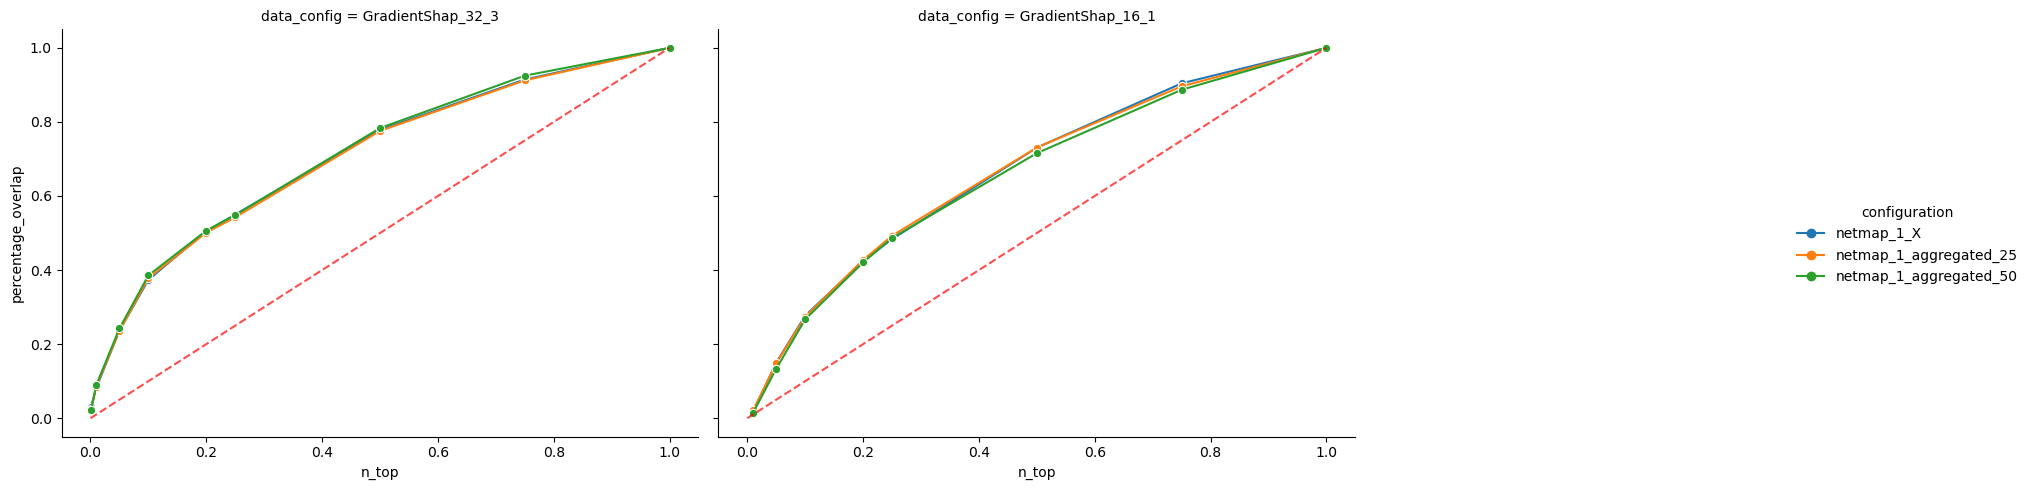

<Figure size 640x480 with 0 Axes>

In [63]:
all_overlaps = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/net_133_10773_net_82_10152_net_72_10551/', select=('GuidedBackprop_64_1_overlaps_global_top_k.tsv'))
all_overlaps2 = read_all_results('/data_nfs/og86asub/netmap/netmap-evaluation/results/summaries_new/net_133_10773_net_82_10152_net_72_10551/', select=('GuidedBackprop_32_3_overlaps_global_top_k.tsv'))

#scgenerai = process_results(scgenerai)
all_overlaps = process_results(all_overlaps)
all_overlaps['data_config'] = 'GradientShap_32_3'

all_overlaps2 = process_results(all_overlaps2)
all_overlaps2['data_config'] = 'GradientShap_16_1'

all_overlaps_sub  = all_overlaps.loc[(all_overlaps.target == 'on_target') & (all_overlaps.net_type=='strict') & (all_overlaps.direction=='reverse') & (all_overlaps.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration', 'data_config']]
all_overlaps_sub2  = all_overlaps2.loc[(all_overlaps.target == 'on_target') & (all_overlaps2.net_type=='strict') & (all_overlaps2.direction=='reverse') & (all_overlaps2.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration', 'data_config']]

all_overlaps_sub = pd.concat([all_overlaps_sub, all_overlaps_sub2])
g = sns.relplot(
    data=all_overlaps_sub, # Use the filtered data
    #hue='configuration',
    x='n_top',
    y='percentage_overlap',
    kind='line',
    hue = 'configuration',
    col=  'data_config',
    marker='o',
    height=5, # Height of eall_overlaps_sub  = all_overlaps.loc[(all_overlaps.target == 'on_target') & (all_overlaps.net_type=='strict') & (all_overlaps.direction=='forward') & (all_overlaps.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration', 'data_config']]
    aspect=1.2, # Aspect ratio of each facet (width/height)
    col_wrap = 3,
    errorbar=None
)

# Add the hardcoded x=y line (0 to 1) to every panel
for ax in g.axes.flat:
    # Hardcoding the x and y coordinates to [0, 1]
    ax.plot([0, 1], [0, 1], 
            color='red', 
            linestyle='--', 
            alpha=0.7, 
            linewidth=1.5,
            zorder=5) # Use zorder to ensure the line is on top of other elements

plt.tight_layout()
plt.show()

# 4. Customizations
g.figure.suptitle('On cluster edges by Facet Variable', y=1.03) # Main title for the entire figure
g.set_axis_labels('#top edges', 'Percentage overlap') # Set axis labels for all facets
g.set_titles(col_template="{col_name}") # Customize the title above each panel (optional)

plt.tight_layout()
plt.show()

In [64]:
import scipy.integrate as si
# We assume the line plot computed the mean 'percentage_overlap' for each unique 'n_top' and 'configuration'.
aggregated_data = all_overlaps_sub.groupby(['configuration', 'n_top', 'data_config'])['percentage_overlap'].mean().reset_index()

# 2. Function to compute the area over the diagonal (y > x) for a single group
def compute_area_over_diagonal(group):
    # Ensure data is sorted by x-axis ('n_top') for correct trapezoidal integration
    group = group.sort_values(by='n_top')
    
    # Calculate the vertical distance from the diagonal: f(x) = y - x
    difference = group['percentage_overlap'] - group['n_top']
    
    # We only want the area where the line is above the diagonal (difference > 0).
    # Set negative differences to 0.
    positive_difference = np.maximum(difference, 0)
    
    # Use numpy's trapezoidal rule (numerical integration) to compute the area: 
    # Area = Integral of (y - x) dx over the positive region
    area = si.trapezoid(y=difference, x=group['n_top'])
    return area

# 3. Apply the function to each configuration group
area_results = aggregated_data.groupby(['configuration', 'data_config']).apply(compute_area_over_diagonal).rename('Area Over Diagonal')

# 4. Convert results to a DataFrame and display
area_df = area_results.reset_index()
print("Area Over Diagonal Results:")
area_df

Area Over Diagonal Results:


/tmp/ipykernel_1043600/2204836847.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  area_results = aggregated_data.groupby(['configuration', 'data_config']).apply(compute_area_over_diagonal).rename('Area Over Diagonal')


,configuration,data_config,Area Over Diagonal
0,netmap_1_X,GradientShap_16_1,0.165960
1,netmap_1_X,GradientShap_32_3,0.209364
2,netmap_1_aggregated_25,GradientShap_16_1,0.165346
3,netmap_1_aggregated_25,GradientShap_32_3,0.207112
4,netmap_1_aggregated_50,GradientShap_16_1,0.156495
5,netmap_1_aggregated_50,GradientShap_32_3,0.214465


In [51]:
area_results

configuration           data_config      
netmap_1_X              GradientShap_16_1    0.042160
                        GradientShap_32_3    0.091592
netmap_1_aggregated_25  GradientShap_16_1    0.046658
                        GradientShap_32_3    0.098847
netmap_1_aggregated_50  GradientShap_16_1    0.049663
                        GradientShap_32_3    0.098903
Name: Area Over Diagonal, dtype: float64

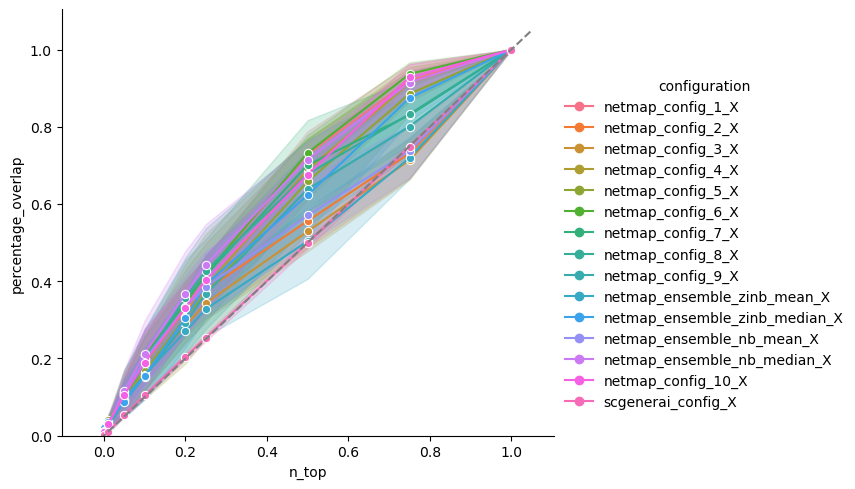

<Figure size 640x480 with 0 Axes>

In [ ]:
#grnb_sub = grnb.loc[grnb.type == 'on_target', :]
#grnb_sub = grnb_sub.loc[:,  ['n_top', 'percentage_overlap', 'configuration']]

all_overlaps_sub  = all_overlaps.loc[(all_overlaps.target == 'on_target') & (all_overlaps.net_type=='unspecific') & (all_overlaps.direction=='forward') & (all_overlaps.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration']]
scgenerai_sub =scgenerai.loc[(scgenerai.target == 'on_target') & (scgenerai.net_type=='strict') & (scgenerai.direction=='forward'), ['n_top', 'percentage_overlap',  'configuration']]
data = pd.concat([ all_overlaps_sub, scgenerai_sub], ignore_index=True)


# 3. Use sns.relplot with 'col' for faceting
g = sns.relplot(
    data=data, # Use the filtered data
    hue='configuration',
    x='n_top',
    y='percentage_overlap',
    kind='line',
    marker='o',
    height=5, # Height of each facet (in inches)
    aspect=1.2 # Aspect ratio of each facet (width/height)
)

for ax in g.axes.flat:
    # Get current x limits for this facet
    xlim = ax.get_xlim()
    # Define line coordinates
    x = np.linspace(xlim[0], xlim[1], 100)
    y = x  # slope = 1, intercept = 0
    
    # Plot the line
    ax.plot(x, y, color='gray', linestyle='--', linewidth=1.5, label='Random (y = x)')
    
    # Optionally adjust y-limits to show the full line
    ax.set_ylim(0, max(ax.get_ylim()[1], xlim[1]))

# Add a shared legend
handles, labels = g.axes[0,0].get_legend_handles_labels()
if 'Random (y = x)' not in labels:
    handles.append(plt.Line2D([], [], color='gray', linestyle='--', label='Random (y = x)'))
    labels.append('Random (y = x)')
    g._legend.remove()
    g.fig.legend(handles, labels, loc='upper center', ncol=3)


plt.show()
# 4. Customizations
g.figure.suptitle('On cluster edges by Facet Variable', y=1.03) # Main title for the entire figure
g.set_axis_labels('#top edges', 'Percentage overlap') # Set axis labels for all facets
g.set_titles(col_template="{col_name}") # Customize the title above each panel (optional)
plt.tight_layout()
plt.show()

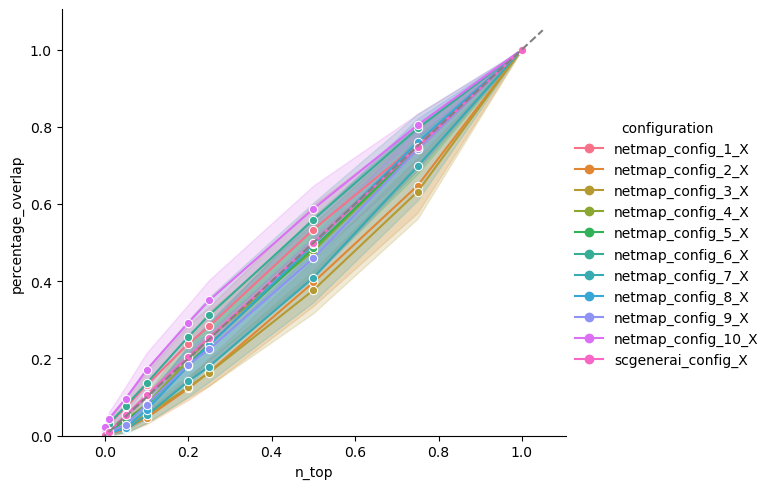

<Figure size 640x480 with 0 Axes>

In [ ]:
#grnb_sub = grnb.loc[grnb.type == 'off_target', :]
#grnb_sub = grnb_sub.loc[:,  ['n_top', 'percentage_overlap', 'configuration']]

all_overlaps_sub  = all_overlaps.loc[(all_overlaps.target == 'off_target') & (all_overlaps.net_type=='strict') & (all_overlaps.direction=='forward') & (all_overlaps.configuration != 'scgenerai_config_X'), ['n_top', 'percentage_overlap',  'configuration']]
scgenerai_sub =scgenerai.loc[(scgenerai.target == 'on_target') & (scgenerai.net_type=='strict') & (scgenerai.direction=='forward'), ['n_top', 'percentage_overlap',  'configuration']]
data = pd.concat([all_overlaps_sub, scgenerai_sub], ignore_index=True)


# 3. Use sns.relplot with 'col' for faceting
g = sns.relplot(
    data=data, # Use the filtered data
    hue='configuration',
    x='n_top',
    y='percentage_overlap',
    kind='line',
    marker='o',
    height=5, # Height of each facet (in inches)
    aspect=1.2 # Aspect ratio of each facet (width/height)
)

for ax in g.axes.flat:
    # Get current x limits for this facet
    xlim = ax.get_xlim()
    # Define line coordinates
    x = np.linspace(xlim[0], xlim[1], 100)
    y = x  # slope = 1, intercept = 0
    
    # Plot the line
    ax.plot(x, y, color='gray', linestyle='--', linewidth=1.5, label='Random (y = x)')
    
    # Optionally adjust y-limits to show the full line
    ax.set_ylim(0, max(ax.get_ylim()[1], xlim[1]))

# Add a shared legend
handles, labels = g.axes[0,0].get_legend_handles_labels()
if 'Random (y = x)' not in labels:
    handles.append(plt.Line2D([], [], color='gray', linestyle='--', label='Random (y = x)'))
    labels.append('Random (y = x)')
    g._legend.remove()
    g.fig.legend(handles, labels, loc='upper center', ncol=3)


plt.show()
# 4. Customizations
g.figure.suptitle('On cluster edges by Facet Variable', y=1.03) # Main title for the entire figure
g.set_axis_labels('#top edges', 'Percentage overlap') # Set axis labels for all facets
g.set_titles(col_template="{col_name}") # Customize the title above each panel (optional)
plt.tight_layout()
plt.show()